In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('./cdata/final_ecommerce_dataset.csv')
df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,1,credit_card,2,146.87,88b8b52d46df026a9d1ad2136a59b30b,4,NaN,NaN,2017-05-26 00:00:00,2017-05-30 22:34:40
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,1,credit_card,8,335.48,02fc48a9efa3e3d0f1a8ea26507eeec3,5,NaN,NaN,2018-01-30 00:00:00,2018-02-10 22:43:29
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,1,credit_card,7,157.73,5ad6695d76ee186dc473c42706984d87,5,NaN,NaN,2018-06-15 00:00:00,2018-06-15 12:10:59
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,1,credit_card,1,173.30,059a801bb31f6aab2266e672cab87bc5,5,NaN,NaN,2018-03-29 00:00:00,2018-04-02 18:36:47
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,1,credit_card,8,252.25,8490879d58d6c5d7773f2739a03f089a,5,a melhor nota,O baratheon è esxelente Amo adoro o baratheon,2018-08-10 00:00:00,2018-08-17 01:59:52


In [3]:
df.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state', 'order_id', 'order_status',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'order_item_id', 'product_id',
       'seller_id', 'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'seller_zip_code_prefix', 'seller_city', 'seller_state',
       'payment_sequential', 'payment_type', 'payment_installments',
       'payment_value', 'review_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='str')

In [4]:
print("=== DROP IRRELEVANT COLUMNS ===\n")

# Columns to drop
columns_to_drop = [
    'product_name_lenght',           # Length of product name (not useful)
    'product_description_lenght',     # Length of description (not useful)
    'product_photos_qty',            # Number of photos (not useful)
    'product_weight_g',              # Product weight (not useful for analysis)
    'product_length_cm',             # Product dimensions (not useful)
    'product_height_cm',             
    'product_width_cm',
    'review_comment_title',          # Review title (not useful)
    'review_comment_message'         # Review message (not useful)
]

print("Columns to drop:")
for col in columns_to_drop:
    print(f"  - {col}")

# Drop columns
df_clean = df.drop(columns=columns_to_drop)

print(f"\nBefore: {df.shape}")
print(f"After: {df_clean.shape}")
print(f"Removed: {len(columns_to_drop)} columns")
print(f"Remaining columns: {len(df_clean.columns)}")

print("\nRemaining columns:")
print(df_clean.columns.tolist())

=== DROP IRRELEVANT COLUMNS ===

Columns to drop:
  - product_name_lenght
  - product_description_lenght
  - product_photos_qty
  - product_weight_g
  - product_length_cm
  - product_height_cm
  - product_width_cm
  - review_comment_title
  - review_comment_message

Before: (117329, 39)
After: (117329, 30)
Removed: 9 columns
Remaining columns: 30

Remaining columns:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'review_id', 'review_score', 'review_creation_date', 'review_answer_timestamp']


In [5]:
print("=== CHECK NULLS ===")
print(f"order_delivered_customer_date nulls: {df['order_delivered_customer_date'].isna().sum()}")
print(f"order_estimated_delivery_date nulls: {df['order_estimated_delivery_date'].isna().sum()}")

=== CHECK NULLS ===
order_delivered_customer_date nulls: 2471
order_estimated_delivery_date nulls: 0


In [6]:
print("=== NULL DELIVERY DATES ===")
null_df = df[df['order_delivered_customer_date'].isna()]
print(f"Total rows with null delivery date: {len(null_df)}")
print("\nOrder status distribution:")
print(null_df['order_status'].value_counts())

print("\n" + "="*40)
print("If status is NOT 'delivered' → drop them")
print("If status is 'delivered' → data error, investigate")

=== NULL DELIVERY DATES ===
Total rows with null delivery date: 2471

Order status distribution:
order_status
shipped        1167
canceled        546
invoiced        370
processing      370
delivered         8
unavailable       7
approved          3
Name: count, dtype: int64

If status is NOT 'delivered' → drop them
If status is 'delivered' → data error, investigate


In [7]:
print("=== CHECK 8 'DELIVERED' WITH NULL DATES ===")
delivered_null = df[(df['order_status'] == 'delivered') & (df['order_delivered_customer_date'].isna())]

print(f"Count: {len(delivered_null)}")
print("\nCheck order_delivered_carrier_date:")
print(f"Nulls: {delivered_null['order_delivered_carrier_date'].isna().sum()}")

print("\nCheck order_purchase_timestamp:")
print(f"Nulls: {delivered_null['order_purchase_timestamp'].isna().sum()}")

print("\nSample rows:")
print(delivered_null[['order_id', 'order_status', 'order_purchase_timestamp', 'order_delivered_carrier_date']].head(5))

=== CHECK 8 'DELIVERED' WITH NULL DATES ===
Count: 8

Check order_delivered_carrier_date:
Nulls: 1

Check order_purchase_timestamp:
Nulls: 0

Sample rows:
                                order_id order_status  \
10692   f5dd62b788049ad9fc0526e3ad11a097    delivered   
14180   20edc82cf5400ce95e1afacc25798b31    delivered   
15775   2ebdfc4f15f23b91474edf87475f108e    delivered   
61031   2d1e2d5bf4dc7227b3bfebb81328c15f    delivered   
100820  ab7c89dc1bf4a1ead9d6ec1ec8968a84    delivered   

       order_purchase_timestamp order_delivered_carrier_date  
10692       2018-06-20 06:58:43          2018-06-25 08:05:00  
14180       2018-06-27 16:09:12          2018-07-03 19:26:00  
15775       2018-07-01 17:05:11          2018-07-03 13:57:00  
61031       2017-11-28 17:44:07          2017-11-30 18:12:23  
100820      2018-06-08 12:09:39          2018-06-12 14:10:00  


In [8]:
print("=== CREATE ON-TIME DELIVERY FLAG ===\n")

# Convert to datetime
df_clean['order_delivered_customer_date'] = pd.to_datetime(df_clean['order_delivered_customer_date'])
df_clean['order_estimated_delivery_date'] = pd.to_datetime(df_clean['order_estimated_delivery_date'])

# Create on-time delivery flag
df_clean['on_time_delivery'] = (df_clean['order_delivered_customer_date'] <= df_clean['order_estimated_delivery_date']).astype(int)

print(f"On-time deliveries: {df_clean['on_time_delivery'].sum()}")
print(f"Late deliveries: {len(df_clean) - df_clean['on_time_delivery'].sum()}")


# Drop the 2 columns
df_clean = df_clean.drop(columns=['order_delivered_customer_date', 'order_estimated_delivery_date'])

print(f"\nAfter dropping columns: {df_clean.shape}")
print(f"Remaining columns: {df_clean.columns.tolist()}")

=== CREATE ON-TIME DELIVERY FLAG ===

On-time deliveries: 105998
Late deliveries: 11331

After dropping columns: (117329, 29)
Remaining columns: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'review_id', 'review_score', 'review_creation_date', 'review_answer_timestamp', 'on_time_delivery']


In [9]:
print("=== DROP ORDER_DELIVERED_CARRIER_DATE ===\n")

print("Before dropping:", df_clean.shape)
df_clean = df_clean.drop(columns=['order_delivered_carrier_date'])
print("After dropping:", df_clean.shape)
print("Remaining columns:", df_clean.columns.tolist())

=== DROP ORDER_DELIVERED_CARRIER_DATE ===

Before dropping: (117329, 29)
After dropping: (117329, 28)
Remaining columns: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'review_id', 'review_score', 'review_creation_date', 'review_answer_timestamp', 'on_time_delivery']


In [10]:
len(df_clean.columns)

28

In [11]:
print("=== REMOVE NULL ORDER_APPROVED_AT ===\n")

print(f"Before: {df_clean.shape}")
print(f"Null order_approved_at: {df_clean['order_approved_at'].isna().sum()}")

df_clean = df_clean.dropna(subset=['order_approved_at'])

print(f"After: {df_clean.shape}")


=== REMOVE NULL ORDER_APPROVED_AT ===

Before: (117329, 28)
Null order_approved_at: 15
After: (117314, 28)


In [12]:
print("=== CREATE APPROVAL_TIME & DROP BOTH ===\n")

print(f"\nShape: {df_clean.shape}")
df_clean['order_purchase_timestamp'] = pd.to_datetime(df_clean['order_purchase_timestamp'])
df_clean['order_approved_at'] = pd.to_datetime(df_clean['order_approved_at'])
df_clean['approval_time'] = df_clean['order_approved_at'] - df_clean['order_purchase_timestamp']

df_clean = df_clean.drop(columns=['order_purchase_timestamp', 'order_approved_at'])
print(f"\nShape: {df_clean.shape}")

=== CREATE APPROVAL_TIME & DROP BOTH ===


Shape: (117314, 28)

Shape: (117314, 27)


In [13]:
print("=== FILL NULL CATEGORY ===\n")
print(f"Before: {df_clean['product_category_name'].isna().sum()} nulls")
df_clean['product_category_name'] = df_clean['product_category_name'].fillna('Unknown Category')
print(f"After: {df_clean['product_category_name'].isna().sum()} nulls")

=== FILL NULL CATEGORY ===

Before: 1694 nulls
After: 0 nulls


In [14]:
df_clean.isna().sum().sum()

np.int64(0)

<Axes: title={'center': 'All Categories by Sales'}, xlabel='product_category_name'>

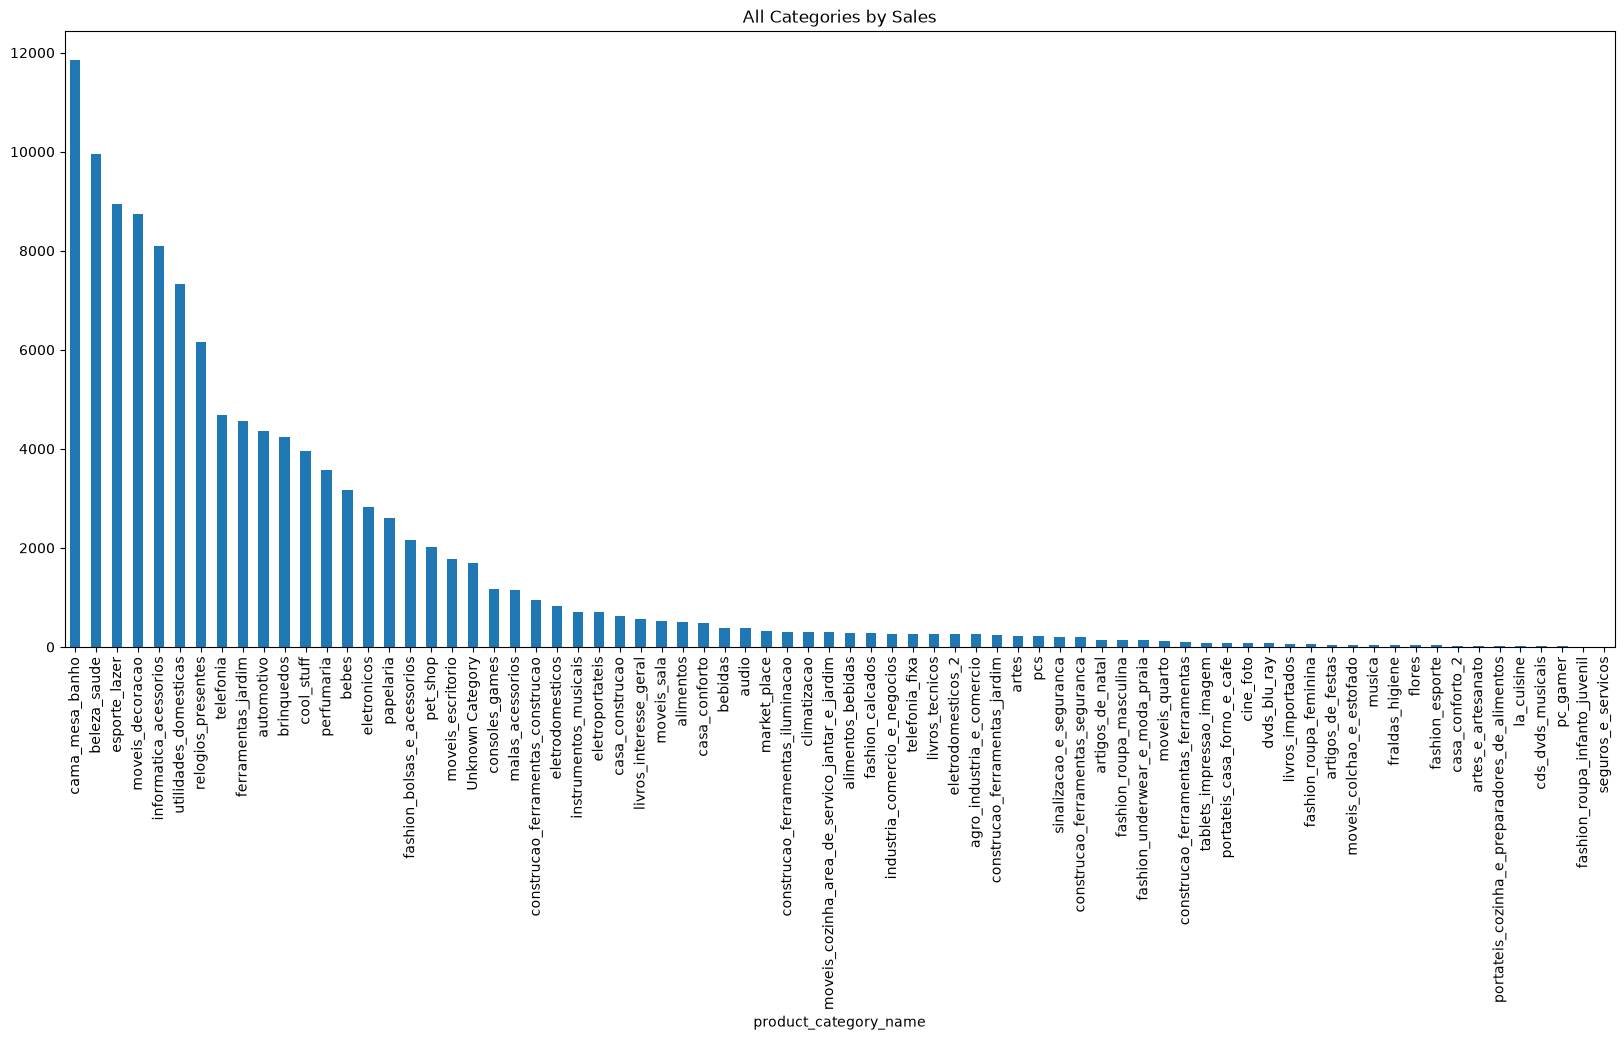

In [15]:
df_clean['product_category_name'].value_counts().plot(kind='bar', figsize=(20,8), title='All Categories by Sales')

In [16]:
print("=== STATISTICS ON CATEGORY SALES ===\n")

# Get value counts
category_counts = df_clean['product_category_name'].value_counts()

print(f"Total categories: {len(category_counts)}")
print(f"Mean: {category_counts.mean():.2f}")
print(f"Median: {category_counts.median():.2f}")
print(f"Mode: {category_counts.mode().tolist()}")
print(f"Standard Deviation: {category_counts.std():.2f}")
print(f"Min: {category_counts.min()}")
print(f"Max: {category_counts.max()}")

print("\nQuartiles:")
print(f"Q1 (25%): {category_counts.quantile(0.25)}")
print(f"Q2 (50%): {category_counts.quantile(0.50)}")
print(f"Q3 (75%): {category_counts.quantile(0.75)}")

print("\nSummary:")
print(category_counts.describe())

=== STATISTICS ON CATEGORY SALES ===

Total categories: 74
Mean: 1585.32
Median: 293.50
Mode: [269]
Standard Deviation: 2676.99
Min: 2
Max: 11846

Quartiles:
Q1 (25%): 79.75
Q2 (50%): 293.5
Q3 (75%): 1753.25

Summary:
count       74.000000
mean      1585.324324
std       2676.986422
min          2.000000
25%         79.750000
50%        293.500000
75%       1753.250000
max      11846.000000
Name: count, dtype: float64


In [17]:
print("=== CREATE DEMAND CATEGORIES ===\n")

# Get value counts
category_counts = df_clean['product_category_name'].value_counts()

# Define demand tiers based on statistics
def demand_tier(count):
    if count >= 5000:
        return 'Very High Demand'
    elif count >= 1753:  # Q3
        return 'High Demand'
    elif count >= 293:   # Median
        return 'Medium Demand'
    elif count >= 79:    # Q1
        return 'Low Demand'
    else:
        return 'Very Low Demand'

# Create demand category column
df_clean['demand_category'] = df_clean['product_category_name'].map(lambda x: demand_tier(category_counts[x]))

print("Demand category distribution:")
print(df_clean['demand_category'].value_counts())

print("\n" + "="*50)

# Drop product_category_name
df_clean = df_clean.drop(columns=['product_category_name'])

print(f"Shape after dropping: {df_clean.shape}")
print(f"Columns: {df_clean.columns.tolist()}")

=== CREATE DEMAND CATEGORIES ===

Demand category distribution:
demand_category
Very High Demand    61067
High Demand         39949
Medium Demand       11906
Low Demand           3714
Very Low Demand       678
Name: count, dtype: int64

Shape after dropping: (117314, 27)
Columns: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_id', 'order_status', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'review_id', 'review_score', 'review_creation_date', 'review_answer_timestamp', 'on_time_delivery', 'approval_time', 'demand_category']


In [18]:
print("\nPercentage:")
print(df_clean['demand_category'].value_counts(normalize=True) * 100)


Percentage:
demand_category
Very High Demand    52.054316
High Demand         34.053054
Medium Demand       10.148831
Low Demand           3.165863
Very Low Demand      0.577936
Name: proportion, dtype: float64


In [19]:
len(df_clean.columns)

27

In [20]:
print("=== CUSTOMER ORDER ANALYSIS ===\n")
customer_orders = df_clean.groupby('customer_unique_id')['order_id'].nunique()
print("Customer Orders:")
print(f"   Min: {customer_orders.min()}")
print(f"   Max: {customer_orders.max()}")
print(f"   Mean: {customer_orders.mean():.2f}")
print(f"   Median: {customer_orders.median():.2f}")
print(f"   Std: {customer_orders.std():.2f}")

print("\n=== SELLER PRODUCT ANALYSIS ===\n")
seller_products = df_clean.groupby('seller_id')['product_id'].count()
print("Seller Products Sold:")
print(f"   Min: {seller_products.min()}")
print(f"   Max: {seller_products.max()}")
print(f"   Mean: {seller_products.mean():.2f}")
print(f"   Median: {seller_products.median():.2f}")
print(f"   Std: {seller_products.std():.2f}")

print("\n=== PRODUCT ORDER ANALYSIS ===\n")
product_orders = df_clean.groupby('product_id')['order_id'].nunique()
print("Product Orders:")
print(f"   Min: {product_orders.min()}")
print(f"   Max: {product_orders.max()}")
print(f"   Mean: {product_orders.mean():.2f}")
print(f"   Median: {product_orders.median():.2f}")
print(f"   Std: {product_orders.std():.2f}")

print("\n=== CUSTOMER SPENDING ANALYSIS ===\n")
customer_spent = df_clean.groupby('customer_unique_id')['payment_value'].sum()
print("Customer Total Spending:")
print(f"   Min: {customer_spent.min():.2f}")
print(f"   Max: {customer_spent.max():.2f}")
print(f"   Mean: {customer_spent.mean():.2f}")
print(f"   Median: {customer_spent.median():.2f}")
print(f"   Std: {customer_spent.std():.2f}")

print("\n=== SELLER REVENUE ANALYSIS ===\n")
seller_revenue = df_clean.groupby('seller_id')['price'].sum()
print("Seller Total Revenue:")
print(f"   Min: {seller_revenue.min():.2f}")
print(f"   Max: {seller_revenue.max():.2f}")
print(f"   Mean: {seller_revenue.mean():.2f}")
print(f"   Median: {seller_revenue.median():.2f}")
print(f"   Std: {seller_revenue.std():.2f}")

=== CUSTOMER ORDER ANALYSIS ===

Customer Orders:
   Min: 1
   Max: 16
   Mean: 1.03
   Median: 1.00
   Std: 0.21

=== SELLER PRODUCT ANALYSIS ===

Seller Products Sold:
   Min: 1
   Max: 2128
   Mean: 37.97
   Median: 8.00
   Std: 124.50

=== PRODUCT ORDER ANALYSIS ===

Product Orders:
   Min: 1
   Max: 458
   Mean: 3.10
   Median: 1.00
   Std: 9.40

=== CUSTOMER SPENDING ANALYSIS ===

Customer Total Spending:
   Min: 9.59
   Max: 109312.64
   Mean: 213.14
   Median: 113.16
   Std: 630.18

=== SELLER REVENUE ANALYSIS ===

Seller Total Revenue:
   Min: 3.50
   Max: 242591.55
   Mean: 4575.84
   Median: 842.90
   Std: 14558.24


In [21]:
len(df_clean.columns)

27

In [22]:
print("=== STATISTICS FOR IMPORTANT COLUMNS ===\n")

# 1. Customer order count
customer_orders = df_clean.groupby('customer_unique_id')['order_id'].nunique()
print("1. Customer Orders:")
print(f"   Min: {customer_orders.min()}")
print(f"   Max: {customer_orders.max()}")
print(f"   Mean: {customer_orders.mean():.2f}")
print(f"   Std: {customer_orders.std():.2f}")

# 2. Price
print("\n2. Price:")
print(f"   Min: {df_clean['price'].min():.2f}")
print(f"   Max: {df_clean['price'].max():.2f}")
print(f"   Mean: {df_clean['price'].mean():.2f}")
print(f"   Std: {df_clean['price'].std():.2f}")

# 3. Freight Value
print("\n3. Freight Value:")
print(f"   Min: {df_clean['freight_value'].min():.2f}")
print(f"   Max: {df_clean['freight_value'].max():.2f}")
print(f"   Mean: {df_clean['freight_value'].mean():.2f}")
print(f"   Std: {df_clean['freight_value'].std():.2f}")

# 4. Payment Value
print("\n4. Payment Value:")
print(f"   Min: {df_clean['payment_value'].min():.2f}")
print(f"   Max: {df_clean['payment_value'].max():.2f}")
print(f"   Mean: {df_clean['payment_value'].mean():.2f}")
print(f"   Std: {df_clean['payment_value'].std():.2f}")

# 5. Payment Installments
print("\n5. Payment Installments:")
print(f"   Min: {df_clean['payment_installments'].min()}")
print(f"   Max: {df_clean['payment_installments'].max()}")
print(f"   Mean: {df_clean['payment_installments'].mean():.2f}")
print(f"   Std: {df_clean['payment_installments'].std():.2f}")

# 6. Review Score
print("\n6. Review Score:")
print(f"   Min: {df_clean['review_score'].min()}")
print(f"   Max: {df_clean['review_score'].max()}")
print(f"   Mean: {df_clean['review_score'].mean():.2f}")
print(f"   Std: {df_clean['review_score'].std():.2f}")

# 7. Approval Time (convert to hours)
print("\n7. Approval Time (hours):")
approval_hours = df_clean['approval_time'].dt.total_seconds() / 3600
print(f"   Min: {approval_hours.min():.2f}")
print(f"   Max: {approval_hours.max():.2f}")
print(f"   Mean: {approval_hours.mean():.2f}")
print(f"   Std: {approval_hours.std():.2f}")

=== STATISTICS FOR IMPORTANT COLUMNS ===

1. Customer Orders:
   Min: 1
   Max: 16
   Mean: 1.03
   Std: 0.21

2. Price:
   Min: 0.85
   Max: 6735.00
   Mean: 120.53
   Std: 182.95

3. Freight Value:
   Min: 0.00
   Max: 409.68
   Mean: 20.03
   Std: 15.83

4. Payment Value:
   Min: 0.00
   Max: 13664.08
   Mean: 172.07
   Std: 265.40

5. Payment Installments:
   Min: 0
   Max: 24
   Mean: 2.94
   Std: 2.78

6. Review Score:
   Min: 1
   Max: 5
   Mean: 4.03
   Std: 1.39

7. Approval Time (hours):
   Min: 0.00
   Max: 1450.87
   Mean: 10.50
   Std: 22.23


<Axes: title={'center': 'Customer Orders Distribution'}, ylabel='Frequency'>

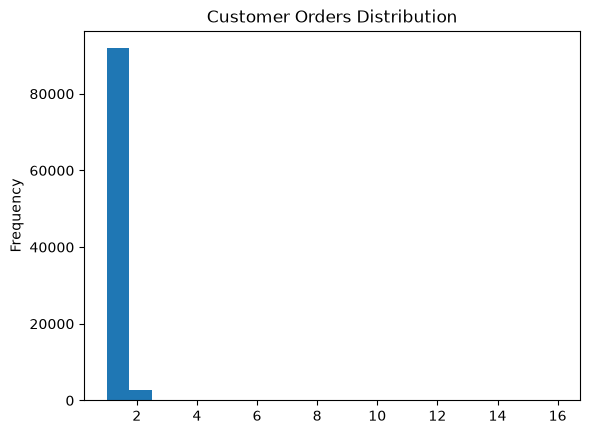

In [23]:
customer_orders = df_clean.groupby('customer_unique_id')['order_id'].nunique()
customer_orders.plot(kind='hist', bins=20, title='Customer Orders Distribution')

<Axes: title={'center': 'Price Distribution'}, ylabel='Frequency'>

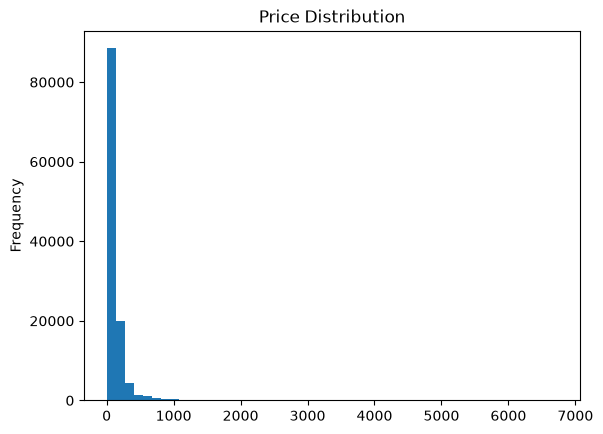

In [24]:
df_clean['price'].plot(kind='hist', bins=50, title='Price Distribution')

<Axes: title={'center': 'Freight Value Distribution'}, ylabel='Frequency'>

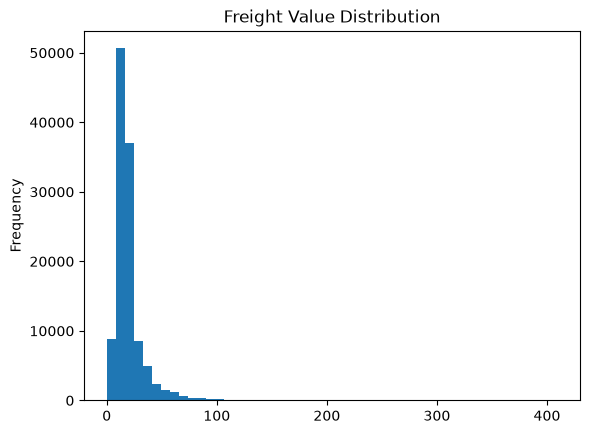

In [25]:
df_clean['freight_value'].plot(kind='hist', bins=50, title='Freight Value Distribution')

<Axes: title={'center': 'Payment Value Distribution'}, ylabel='Frequency'>

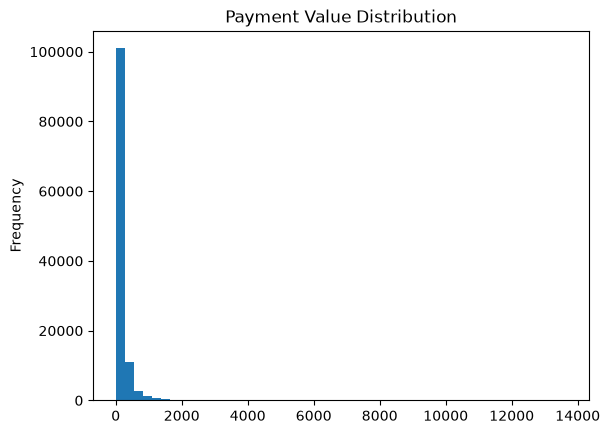

In [26]:
df_clean['payment_value'].plot(kind='hist', bins=50, title='Payment Value Distribution')

<Axes: title={'center': 'Payment Installments Distribution'}, ylabel='Frequency'>

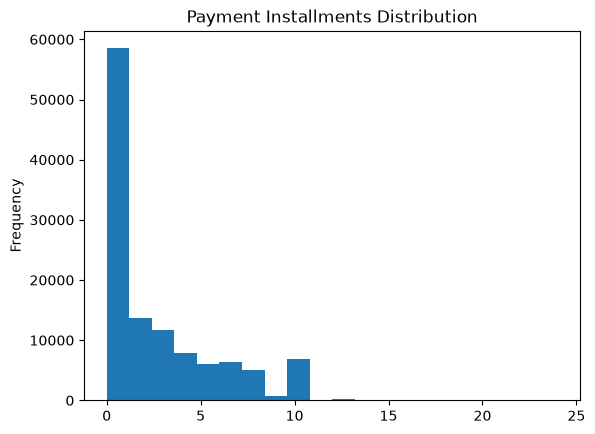

In [27]:
df_clean['payment_installments'].plot(kind='hist', bins=20, title='Payment Installments Distribution')

<Axes: title={'center': 'Review Score Distribution'}, ylabel='Frequency'>

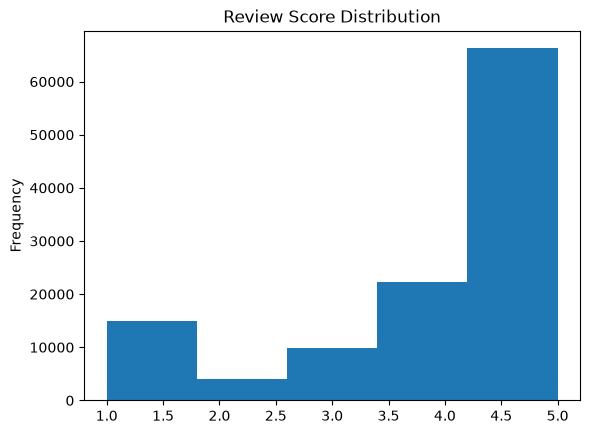

In [28]:
df_clean['review_score'].plot(kind='hist', bins=5, title='Review Score Distribution')

<Axes: title={'center': 'Approval Time Distribution (hours)'}, ylabel='Frequency'>

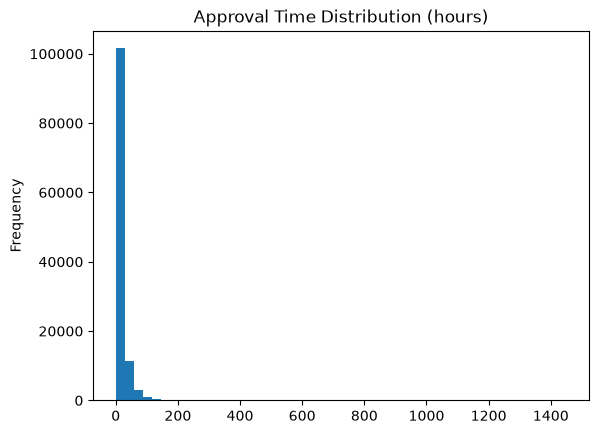

In [29]:
approval_hours = df_clean['approval_time'].dt.total_seconds() / 3600
approval_hours.plot(kind='hist', bins=50, title='Approval Time Distribution (hours)')

In [30]:
len(df_clean.columns)

27

In [31]:
print("=== CITY & STATE STATISTICS ===\n")

# Customer City
print("1. Customer City:")
print(f"   Unique cities: {df['customer_city'].nunique()}")
city_orders = df['customer_city'].value_counts()
print(f"   Min orders in a city: {city_orders.min()}")
print(f"   Max orders in a city: {city_orders.max()}")
print(f"   Mean orders per city: {city_orders.mean():.2f}")
print(f"   Std orders per city: {city_orders.std():.2f}")

# Customer State
print("\n2. Customer State:")
print(f"   Unique states: {df['customer_state'].nunique()}")
state_orders = df['customer_state'].value_counts()
print(f"   Min orders in a state: {state_orders.min()}")
print(f"   Max orders in a state: {state_orders.max()}")
print(f"   Mean orders per state: {state_orders.mean():.2f}")
print(f"   Std orders per state: {state_orders.std():.2f}")

# Seller City
print("\n3. Seller City:")
print(f"   Unique cities: {df['seller_city'].nunique()}")
seller_city_orders = df['seller_city'].value_counts()
print(f"   Min orders from a city: {seller_city_orders.min()}")
print(f"   Max orders from a city: {seller_city_orders.max()}")
print(f"   Mean orders per city: {seller_city_orders.mean():.2f}")
print(f"   Std orders per city: {seller_city_orders.std():.2f}")

# Seller State
print("\n4. Seller State:")
print(f"   Unique states: {df['seller_state'].nunique()}")
seller_state_orders = df['seller_state'].value_counts()
print(f"   Min orders from a state: {seller_state_orders.min()}")
print(f"   Max orders from a state: {seller_state_orders.max()}")
print(f"   Mean orders per state: {seller_state_orders.mean():.2f}")
print(f"   Std orders per state: {seller_state_orders.std():.2f}")

=== CITY & STATE STATISTICS ===

1. Customer City:
   Unique cities: 4108
   Min orders in a city: 1
   Max orders in a city: 18582
   Mean orders per city: 28.56
   Std orders per city: 333.49

2. Customer State:
   Unique states: 27
   Min orders in a state: 52
   Max orders in a state: 49527
   Mean orders per state: 4345.52
   Std orders per state: 9808.49

3. Seller City:
   Unique cities: 611
   Min orders from a city: 1
   Max orders from a city: 29048
   Mean orders per city: 192.03
   Std orders per city: 1268.37

4. Seller State:
   Unique states: 23
   Min orders from a state: 1
   Max orders from a state: 83671
   Mean orders per state: 5101.26
   Std orders per state: 17345.80


In [32]:
print("=== TOP & BOTTOM CITIES AND STATES ===\n")

# Top 5 cities
print("Top 5 Cities by Orders:")
print(df_clean['customer_city'].value_counts().head(5))
print("\nBottom 5 Cities by Orders:")
print(df_clean['customer_city'].value_counts().tail(5))

# Top 5 states
print("\nTop 5 States by Orders:")
print(df_clean['customer_state'].value_counts().head(5))
print("\nBottom 5 States by Orders:")
print(df_clean['customer_state'].value_counts().tail(5))

# Top 5 cities with best on-time delivery
city_ontime = df_clean.groupby('customer_city')['on_time_delivery'].mean().sort_values(ascending=False)
print("\nTop 5 Cities with Best On-Time Delivery:")
print(city_ontime.head(5))
print("\nBottom 5 Cities with Worst On-Time Delivery:")
print(city_ontime.tail(5))

# Top 5 states with best on-time delivery
state_ontime = df_clean.groupby('customer_state')['on_time_delivery'].mean().sort_values(ascending=False)
print("\nTop 5 States with Best On-Time Delivery:")
print(state_ontime.head(5))
print("\nBottom 5 States with Worst On-Time Delivery:")
print(state_ontime.tail(5))

# Top 5 cities with best review scores
city_review = df_clean.groupby('customer_city')['review_score'].mean().sort_values(ascending=False)
print("\nTop 5 Cities with Best Review Scores:")
print(city_review.head(5))
print("\nBottom 5 Cities with Worst Review Scores:")
print(city_review.tail(5))

# Top 5 states with best review scores
state_review = df_clean.groupby('customer_state')['review_score'].mean().sort_values(ascending=False)
print("\nTop 5 States with Best Review Scores:")
print(state_review.head(5))
print("\nBottom 5 States with Worst Review Scores:")
print(state_review.tail(5))

=== TOP & BOTTOM CITIES AND STATES ===

Top 5 Cities by Orders:
customer_city
sao paulo         18580
rio de janeiro     8156
belo horizonte     3252
brasilia           2466
curitiba           1807
Name: count, dtype: int64

Bottom 5 Cities by Orders:
customer_city
uniao dos palmares     1
natividade da serra    1
monte bonito           1
sao rafael             1
eugenio de castro      1
Name: count, dtype: int64

Top 5 States by Orders:
customer_state
SP    49522
RJ    15217
MG    13613
RS     6514
PR     5959
Name: count, dtype: int64

Bottom 5 States by Orders:
customer_state
RO    285
AM    170
AC     95
AP     83
RR     52
Name: count, dtype: int64

Top 5 Cities with Best On-Time Delivery:
customer_city
zortea                 1.0
abadia dos dourados    1.0
abadiania              1.0
xique-xique            1.0
xexeu                  1.0
Name: on_time_delivery, dtype: float64

Bottom 5 Cities with Worst On-Time Delivery:
customer_city
nova brescia       0.0
vicosa do ceara    0.0
vi

In [33]:
len(df_clean.columns)

27

In [34]:
print("=== PAYMENT TYPES ANALYSIS ===\n")

# Payment type distribution
print("Payment Type Distribution:")
print(df['payment_type'].value_counts())
print("\nPercentage:")
print(df['payment_type'].value_counts(normalize=True) * 100)

# Average payment value by payment type
print("\nAverage Payment Value by Payment Type:")
print(df.groupby('payment_type')['payment_value'].mean().sort_values(ascending=False))

# Average installments by payment type
print("\nAverage Installments by Payment Type:")
print(df.groupby('payment_type')['payment_installments'].mean().sort_values(ascending=False))


=== PAYMENT TYPES ANALYSIS ===

Payment Type Distribution:
payment_type
credit_card    86520
boleto         22835
voucher         6282
debit_card      1692
Name: count, dtype: int64

Percentage:
payment_type
credit_card    73.741360
boleto         19.462367
voucher         5.354175
debit_card      1.442099
Name: proportion, dtype: float64

Average Payment Value by Payment Type:
payment_type
credit_card    179.011599
boleto         177.022206
debit_card     150.077825
voucher         64.248868
Name: payment_value, dtype: float64

Average Installments by Payment Type:
payment_type
credit_card    3.631022
boleto         1.000000
debit_card     1.000000
voucher        1.000000
Name: payment_installments, dtype: float64


In [35]:
print("=== PAYMENT VALUE ANALYSIS ===\n")

print(f"Data type: {df['payment_value'].dtypes}")

# Basic statistics
print("\nPayment Value Statistics:")
print(f"Min: {df['payment_value'].min():.2f}")
print(f"Max: {df['payment_value'].max():.2f}")
print(f"Mean: {df['payment_value'].mean():.2f}")
print(f"Median: {df['payment_value'].median():.2f}")
print(f"Std: {df['payment_value'].std():.2f}")

# Distribution by payment type
print("\nPayment Value by Payment Type:")
print(df.groupby('payment_type')['payment_value'].agg(['min', 'max', 'mean', 'median', 'std']))


=== PAYMENT VALUE ANALYSIS ===

Data type: float64

Payment Value Statistics:
Min: 0.00
Max: 13664.08
Mean: 172.06
Median: 108.10
Std: 265.39

Payment Value by Payment Type:
                min       max        mean   median         std
payment_type                                                  
boleto        11.62   7274.88  177.022206  105.770  288.932488
credit_card    0.01  13664.08  179.011599  115.240  265.900975
debit_card    13.38   4445.50  150.077825   97.625  253.347900
voucher        0.00   1839.05   64.248868   39.420   91.852291


In [36]:
print("=== EXTRACT FEATURES FROM DATE COLUMNS ===\n")

# Convert to datetime
df_clean['review_creation_date'] = pd.to_datetime(df_clean['review_creation_date'])
df_clean['review_answer_timestamp'] = pd.to_datetime(df_clean['review_answer_timestamp'])

# Create review_response_time
df_clean['review_response_time'] = df_clean['review_answer_timestamp'] - df_clean['review_creation_date']

# Drop original date columns
df_clean = df_clean.drop(columns=['review_creation_date', 'review_answer_timestamp'])

print(f"Shape: {df_clean.shape}")
print(f"Columns: {df_clean.columns.tolist()}")

=== EXTRACT FEATURES FROM DATE COLUMNS ===

Shape: (117314, 26)
Columns: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_id', 'order_status', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'review_id', 'review_score', 'on_time_delivery', 'approval_time', 'demand_category', 'review_response_time']


In [37]:
len(df_clean.columns)

26

In [38]:
df.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state', 'order_id', 'order_status',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'order_item_id', 'product_id',
       'seller_id', 'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'seller_zip_code_prefix', 'seller_city', 'seller_state',
       'payment_sequential', 'payment_type', 'payment_installments',
       'payment_value', 'review_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='str')

In [39]:
print("=== REVIEW COMMENT MESSAGE ANALYSIS ===\n")

# Get comment lengths without creating column
comment_lengths = df['review_comment_message'].dropna().str.len()

print(f"Mean: {comment_lengths.mean():.2f}")
print(f"Median: {comment_lengths.median():.2f}")
print(f"Mode: {comment_lengths.mode().tolist()}")
print(f"Std: {comment_lengths.std():.2f}")
print(f"Min: {comment_lengths.min()}")
print(f"Max: {comment_lengths.max()}")

=== REVIEW COMMENT MESSAGE ANALYSIS ===

Mean: 70.33
Median: 54.00
Mode: [9]
Std: 54.58
Min: 1
Max: 208


In [40]:
df_clean.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state', 'order_id', 'order_status',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'seller_zip_code_prefix', 'seller_city',
       'seller_state', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value', 'review_id', 'review_score',
       'on_time_delivery', 'approval_time', 'demand_category',
       'review_response_time'],
      dtype='str')

In [41]:
print("=== FINAL ML DATASET ===\n")

# Columns to drop (not needed for ML)
drop_cols = [
    'customer_id',
    'customer_unique_id',
    'customer_zip_code_prefix',
    'customer_city',
    'customer_state',
    'order_id',
    'order_item_id',
    'product_id',
    'seller_id',
    'shipping_limit_date',
    'seller_zip_code_prefix',
    'seller_city',
    'seller_state',
    'payment_sequential',
    'review_id'
]

print("Dropping:")
for col in drop_cols:
    print(f"  - {col}")

df_ml = df_clean.drop(columns=drop_cols)

print(f"\nML shape: {df_ml.shape}")
print(f"ML columns: {df_ml.columns.tolist()}")

=== FINAL ML DATASET ===

Dropping:
  - customer_id
  - customer_unique_id
  - customer_zip_code_prefix
  - customer_city
  - customer_state
  - order_id
  - order_item_id
  - product_id
  - seller_id
  - shipping_limit_date
  - seller_zip_code_prefix
  - seller_city
  - seller_state
  - payment_sequential
  - review_id

ML shape: (117314, 11)
ML columns: ['order_status', 'price', 'freight_value', 'payment_type', 'payment_installments', 'payment_value', 'review_score', 'on_time_delivery', 'approval_time', 'demand_category', 'review_response_time']


In [42]:
# Save as train.csv
df_ml.to_csv('./cdata/train.csv', index=False)
print("✅ Saved as train.csv")
print(f"Shape: {df_ml.shape}")
print(f"Columns: {df_ml.columns.tolist()}")

✅ Saved as train.csv
Shape: (117314, 11)
Columns: ['order_status', 'price', 'freight_value', 'payment_type', 'payment_installments', 'payment_value', 'review_score', 'on_time_delivery', 'approval_time', 'demand_category', 'review_response_time']
